In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import os

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Define the base results directory
results_base_dir = "/data/projects/punim0478/setiawand/bible-nmt/results"

# Function to automatically load all filtered metrics JSON files
def load_gemini_results(base_dir):
    results_data = {}
    
    # Find all gemini-2.5-flash-*-dhao directories
    gemini_dirs = glob.glob(os.path.join(base_dir, "gemini-2.5-flash-*-dhao"))
    
    for gemini_dir in sorted(gemini_dirs):
        # Extract variant name from directory (e.g., "engBBE" from "gemini-2.5-flash-engBBE-dhao")
        dir_name = os.path.basename(gemini_dir)
        variant = dir_name.replace("gemini-2.5-flash-", "").replace("-dhao", "")
        
        print(f"Processing variant: {variant}")
        
        # Find all parallel_* subdirectories
        parallel_dirs = glob.glob(os.path.join(gemini_dir, "parallel_*"))
        
        for parallel_dir in sorted(parallel_dirs):
            training_config = os.path.basename(parallel_dir)
            
            # Look for the filtered metrics JSON file
            json_pattern = os.path.join(parallel_dir, "*-filtered_metrics.json")
            json_files = glob.glob(json_pattern)
            
            # If filtered metrics not found, look for regular metrics JSON file
            if not json_files:
                json_pattern = os.path.join(parallel_dir, "*_metrics.json")
                json_files = glob.glob(json_pattern)
            
            if json_files:
                json_file = json_files[0]  # Take the first match
                print(f"  Loading: {training_config} -> {os.path.basename(json_file)}")
                
                try:
                    with open(json_file, 'r') as f:
                        data = json.load(f)
                    
                    # Create key for this configuration
                    config_key = f"{variant}-{training_config}"
                    results_data[config_key] = data
                    
                except Exception as e:
                    print(f"    Error loading {json_file}: {e}")
            else:
                print(f"    No filtered metrics JSON found in {parallel_dir}")
    
    return results_data

# Load all the data automatically
print("🔍 Automatically discovering and loading JSON files...")
print("=" * 60)

results_data = load_gemini_results(results_base_dir)

print("=" * 60)
print("✅ Data loaded successfully!")
print(f"📊 Total configurations analyzed: {len(results_data)}")

if results_data:
    variants = list(set([key.split('-')[0] for key in results_data.keys()]))
    training_configs = list(set([key.split('-', 1)[1] for key in results_data.keys()]))
    
    print(f"🧬 Variants found: {variants}")
    print(f"⚙️  Training configs: {training_configs}")
    
    # Show a sample of the loaded data
    print(f"\n📋 Sample configuration: {list(results_data.keys())[0]}")
    sample_data = results_data[list(results_data.keys())[0]]
    print(f"   Metrics available: {list(sample_data.keys())}")
else:
    print("❌ No data found! Please check the directory structure.")


🔍 Automatically discovering and loading JSON files...
Processing variant: engBBE
  Loading: parallel_full -> gemini-2.5-flash_aligned-eng-engBBE-ot_eng_nfa-filtered_metrics.json
  Loading: parallel_full+nt -> gemini-2.5-flash_aligned-eng-engBBE-ot_eng_nfa-filtered_metrics.json
  Loading: parallel_nt -> gemini-2.5-flash_aligned-eng-engBBE-ot_eng_nfa-filtered_metrics.json
Processing variant: englsv
  Loading: parallel_full+nt -> gemini-2.5-flash_aligned-eng-englsv-ot_eng_nfa_metrics.json
Processing variant: engojb
  Loading: parallel_full+nt -> gemini-2.5-flash_aligned-eng-engojb-ot_eng_nfa_metrics.json
Processing variant: engwyc2017
  Loading: parallel_full -> gemini-2.5-flash_aligned-eng-engwyc2017-ot_eng_nfa-filtered_metrics.json
  Loading: parallel_full+nt -> gemini-2.5-flash_aligned-eng-engwyc2017-ot_eng_nfa-filtered_metrics.json
  Loading: parallel_nt -> gemini-2.5-flash_aligned-eng-engwyc2017-ot_eng_nfa-filtered_metrics.json
Processing variant: engwyc2018
  Loading: parallel_full 

In [2]:
# Convert data to DataFrame for easier analysis
df_rows = []
for config_name, metrics in results_data.items():
    variant, training_config = config_name.split('-', 1)
    
    # Add original metrics
    row_orig = {'variant': variant, 'training_config': training_config, 'metric_type': 'original'}
    row_orig.update(metrics['original_mt_metrics'])
    df_rows.append(row_orig)
    
    # Add post-edited metrics  
    row_pe = {'variant': variant, 'training_config': training_config, 'metric_type': 'post_edited'}
    row_pe.update(metrics['post_edited_metrics'])
    df_rows.append(row_pe)
    
    # Add improvement metrics
    row_imp = {'variant': variant, 'training_config': training_config, 'metric_type': 'improvement'}
    row_imp.update(metrics['improvements'])
    df_rows.append(row_imp)

df = pd.DataFrame(df_rows)

# Create separate DataFrames for different analyses
df_post_edited = df[df['metric_type'] == 'post_edited'].copy()
df_improvements = df[df['metric_type'] == 'improvement'].copy()

print("DataFrame shapes:")
print(f"Full data: {df.shape}")
print(f"Post-edited only: {df_post_edited.shape}")
print(f"Improvements only: {df_improvements.shape}")
print("\nAvailable variants:", df['variant'].unique())
print("Training configurations:", df['training_config'].unique())


DataFrame shapes:
Full data: (45, 9)
Post-edited only: (15, 9)
Improvements only: (15, 9)

Available variants: ['engBBE' 'englsv' 'engojb' 'engwyc2017' 'engwyc2018' 't4t' 'webp']
Training configurations: ['parallel_full' 'parallel_full+nt' 'parallel_nt']


In [3]:
# REVAMPED ANALYSIS: First find best training config for each version, then compare
print("=" * 80)
print("STEP 1: FIND BEST TRAINING CONFIGURATION FOR EACH BIBLE VERSION")
print("=" * 80)

# Focus on the requested metrics only
metrics_to_analyze = ['spbleu', 'chrf++']
print(f"📊 Analyzing metrics: {metrics_to_analyze}")

print("\n🔍 Finding best training configuration for each Bible version...")
print("-" * 60)

best_configs_by_version = {}

for variant in df_improvements['variant'].unique():
    print(f"\n📖 {variant.upper()}:")
    
    variant_data = df_improvements[df_improvements['variant'] == variant]
    
    # Calculate average improvement across the metrics for each training config
    config_scores = {}
    for training_config in variant_data['training_config'].unique():
        config_data = variant_data[variant_data['training_config'] == training_config]
        avg_improvement = config_data[metrics_to_analyze].mean().mean()
        config_scores[training_config] = avg_improvement
        
        print(f"  {training_config:15}: {avg_improvement:7.4f} (avg improvement)")
    
    # Find the best training config for this variant
    best_config = max(config_scores.items(), key=lambda x: x[1])
    best_configs_by_version[variant] = {
        'training_config': best_config[0],
        'avg_improvement': best_config[1]
    }
    
    print(f"  🏆 WINNER: {best_config[0]} ({best_config[1]:.4f})")

print("\n" + "=" * 80)
print("STEP 2: COMPARE BEST CONFIGURATIONS ACROSS BIBLE VERSIONS")
print("=" * 80)

# Create a filtered dataset with only the best configurations
best_config_data = []

for variant in best_configs_by_version.keys():
    best_training_config = best_configs_by_version[variant]['training_config']
    
    # Get the data for this best configuration
    config_key = f"{variant}-{best_training_config}"
    if config_key in results_data:
        best_config_data.append({
            'variant': variant,
            'training_config': best_training_config,
            'config_key': config_key,
            'data': results_data[config_key]
        })

print(f"\n📊 Comparing {len(best_config_data)} best configurations:")
for config in best_config_data:
    print(f"  • {config['variant'].upper()}: {config['training_config']}")

# Create comparison DataFrames with only the best configurations
best_pe_comparison = []
best_imp_comparison = []

for config in best_config_data:
    variant = config['variant']
    training_config = config['training_config']
    data = config['data']
    
    # Post-edited metrics
    pe_row = {'variant': variant, 'training_config': training_config}
    pe_row.update(data['post_edited_metrics'])
    best_pe_comparison.append(pe_row)
    
    # Improvement metrics  
    imp_row = {'variant': variant, 'training_config': training_config}
    imp_row.update(data['improvements'])
    best_imp_comparison.append(imp_row)

best_pe_df = pd.DataFrame(best_pe_comparison)
best_imp_df = pd.DataFrame(best_imp_comparison)

print("\n1. POST-EDITED PERFORMANCE (Best configs only):")
print("-" * 50)

for _, row in best_pe_df.iterrows():
    print(f"\n{row['variant'].upper()} ({row['training_config']}):")
    for metric in metrics_to_analyze:
        print(f"  {metric:10}: {row[metric]:7.4f}")

print("\n2. IMPROVEMENTS (Best configs only):")
print("-" * 40)

for _, row in best_imp_df.iterrows():
    print(f"\n{row['variant'].upper()} ({row['training_config']}):")
    for metric in metrics_to_analyze:
        print(f"  {metric:10}: +{row[metric]:6.4f}")

# Rank the best configurations
print("\n3. FINAL RANKING (Best config from each version):")
print("-" * 55)

# Rank by post-edited performance
pe_rankings = {}
for metric in metrics_to_analyze:
    ranked = best_pe_df.sort_values(metric, ascending=False)
    for i, (_, row) in enumerate(ranked.iterrows()):
        variant = row['variant']
        if variant not in pe_rankings:
            pe_rankings[variant] = []
        pe_rankings[variant].append(i + 1)

avg_pe_rankings = {variant: np.mean(ranks) for variant, ranks in pe_rankings.items()}
sorted_pe_rankings = sorted(avg_pe_rankings.items(), key=lambda x: x[1])

print("\nA. BY POST-EDITED PERFORMANCE:")
for i, (variant, avg_rank) in enumerate(sorted_pe_rankings):
    config = best_configs_by_version[variant]['training_config']
    print(f"  {i+1}. {variant.upper():12} ({config:15}) - Avg rank: {avg_rank:.2f}")

# Rank by improvement
imp_rankings = {}
for metric in metrics_to_analyze:
    ranked = best_imp_df.sort_values(metric, ascending=False)
    for i, (_, row) in enumerate(ranked.iterrows()):
        variant = row['variant']
        if variant not in imp_rankings:
            imp_rankings[variant] = []
        imp_rankings[variant].append(i + 1)

avg_imp_rankings = {variant: np.mean(ranks) for variant, ranks in imp_rankings.items()}
sorted_imp_rankings = sorted(avg_imp_rankings.items(), key=lambda x: x[1])

print("\nB. BY IMPROVEMENT:")
for i, (variant, avg_rank) in enumerate(sorted_imp_rankings):
    config = best_configs_by_version[variant]['training_config']
    print(f"  {i+1}. {variant.upper():12} ({config:15}) - Avg rank: {avg_rank:.2f}")

print(f"\n🏆 OVERALL WINNER (Performance): {sorted_pe_rankings[0][0].upper()}")
print(f"🚀 BEST IMPROVER: {sorted_imp_rankings[0][0].upper()}")


STEP 1: FIND BEST TRAINING CONFIGURATION FOR EACH BIBLE VERSION
📊 Analyzing metrics: ['spbleu', 'chrf++']

🔍 Finding best training configuration for each Bible version...
------------------------------------------------------------

📖 ENGBBE:
  parallel_full  :  5.5928 (avg improvement)
  parallel_full+nt:  9.5380 (avg improvement)
  parallel_nt    :  8.6338 (avg improvement)
  🏆 WINNER: parallel_full+nt (9.5380)

📖 ENGLSV:
  parallel_full+nt:  8.5078 (avg improvement)
  🏆 WINNER: parallel_full+nt (8.5078)

📖 ENGOJB:
  parallel_full+nt: 11.1037 (avg improvement)
  🏆 WINNER: parallel_full+nt (11.1037)

📖 ENGWYC2017:
  parallel_full  :  5.7104 (avg improvement)
  parallel_full+nt:  9.9800 (avg improvement)
  parallel_nt    :  9.9238 (avg improvement)
  🏆 WINNER: parallel_full+nt (9.9800)

📖 ENGWYC2018:
  parallel_full  :  5.4562 (avg improvement)
  parallel_full+nt:  9.7349 (avg improvement)
  parallel_nt    :  9.6913 (avg improvement)
  🏆 WINNER: parallel_full+nt (9.7349)

📖 T4T:
  para


STEP 4: VISUALIZATIONS (Best Configurations Only)


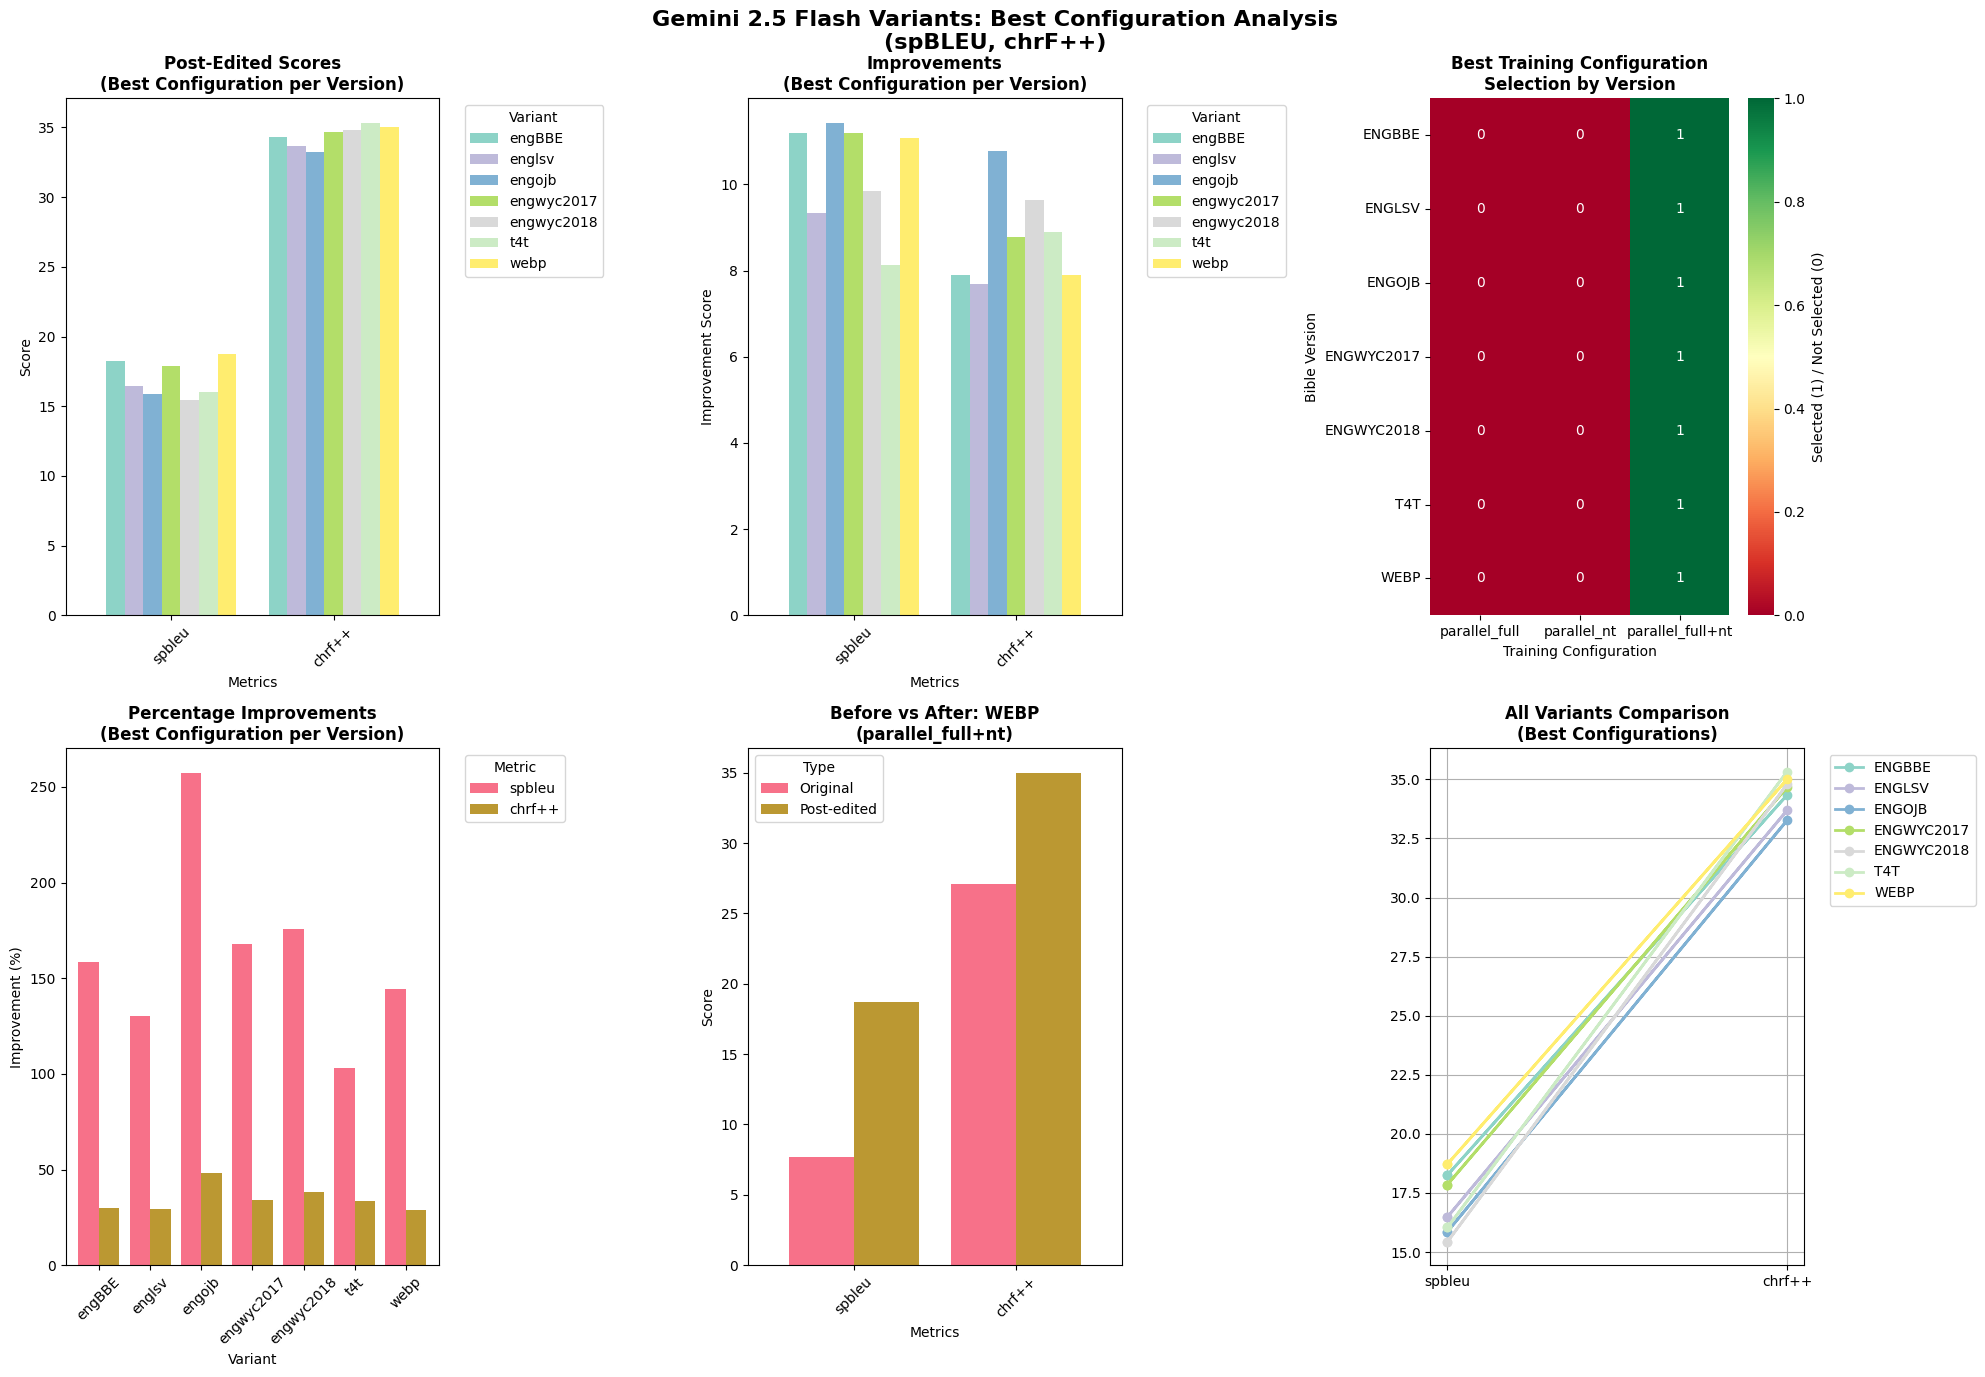

✅ Visualizations created successfully!

📊 Key Insights from Visualizations:
   • Chart 1-2: Direct performance comparison of best configs
   • Chart 3: Shows which training configs work best for each version
   • Chart 4: Percentage improvements highlight relative gains
   • Chart 5: Before/after for the overall winner
   • Chart 6: Radar plot shows strengths across all metrics


In [4]:
# Create comprehensive visualizations for BEST CONFIGURATIONS ONLY
print("\n" + "=" * 80)
print("STEP 4: VISUALIZATIONS (Best Configurations Only)")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
fig.suptitle('Gemini 2.5 Flash Variants: Best Configuration Analysis\n(spBLEU, chrF++)', fontsize=16, fontweight='bold')

# Dynamically generate colors for all variants
num_variants = len(best_config_data)
dynamic_colors = plt.cm.Set3(np.linspace(0, 1, num_variants))

# 1. Post-edited scores (best configs only)
ax1 = axes[0, 0]
best_pe_plot_data = best_pe_df.set_index('variant')[metrics_to_analyze].T
best_pe_plot_data.plot(kind='bar', ax=ax1, width=0.8, color=dynamic_colors)
ax1.set_title('Post-Edited Scores\n(Best Configuration per Version)', fontweight='bold')
ax1.set_xlabel('Metrics')
ax1.set_ylabel('Score')
ax1.legend(title='Variant', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# 2. Improvements (best configs only)
ax2 = axes[0, 1]
best_imp_plot_data = best_imp_df.set_index('variant')[metrics_to_analyze].T
best_imp_plot_data.plot(kind='bar', ax=ax2, width=0.8, color=dynamic_colors)
ax2.set_title('Improvements\n(Best Configuration per Version)', fontweight='bold')
ax2.set_xlabel('Metrics')
ax2.set_ylabel('Improvement Score')
ax2.legend(title='Variant', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=45)

# 3. Training configuration selection heatmap
ax3 = axes[0, 2]
config_matrix = []
variants_ordered = sorted(best_configs_by_version.keys())
all_configs = ['parallel_full', 'parallel_nt', 'parallel_full+nt']

for variant in variants_ordered:
    best_config = best_configs_by_version[variant]['training_config']
    row = [1 if config == best_config else 0 for config in all_configs]
    config_matrix.append(row)

config_df = pd.DataFrame(config_matrix, index=[v.upper() for v in variants_ordered], columns=all_configs)
sns.heatmap(config_df, annot=True, fmt='d', cmap='RdYlGn', ax=ax3, cbar_kws={'label': 'Selected (1) / Not Selected (0)'})
ax3.set_title('Best Training Configuration\nSelection by Version', fontweight='bold')
ax3.set_xlabel('Training Configuration')
ax3.set_ylabel('Bible Version')

# 4. Percentage improvements (best configs only)
ax4 = axes[1, 0]
pct_improvements_best = {}
for config in best_config_data:
    variant = config['variant']
    data = config['data']
    
    pct_improvements_best[variant] = {}
    for metric in metrics_to_analyze:
        orig = data['original_mt_metrics'][metric]
        imp = data['improvements'][metric]
        pct_improvements_best[variant][metric] = (imp / orig) * 100 if orig > 0 else 0

pct_imp_best_df = pd.DataFrame(pct_improvements_best).T
pct_imp_best_df.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_title('Percentage Improvements\n(Best Configuration per Version)', fontweight='bold')
ax4.set_xlabel('Variant')
ax4.set_ylabel('Improvement (%)')
ax4.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.tick_params(axis='x', rotation=45)

# 5. Before vs After comparison for overall winner
ax5 = axes[1, 1]
winner_variant = sorted_pe_rankings[0][0]
winner_config = best_configs_by_version[winner_variant]['training_config']
winner_data = None

for config in best_config_data:
    if config['variant'] == winner_variant:
        winner_data = config['data']
        break

if winner_data:
    comparison_data = pd.DataFrame({
        'Original': [winner_data['original_mt_metrics'][m] for m in metrics_to_analyze],
        'Post-edited': [winner_data['post_edited_metrics'][m] for m in metrics_to_analyze]
    }, index=metrics_to_analyze)
    
    comparison_data.plot(kind='bar', ax=ax5, width=0.8)
    ax5.set_title(f'Before vs After: {winner_variant.upper()}\n({winner_config})', fontweight='bold')
    ax5.set_xlabel('Metrics')
    ax5.set_ylabel('Score')
    ax5.legend(title='Type')
    ax5.tick_params(axis='x', rotation=45)

# 6. Radar plot for all variants (best configs)
ax6 = axes[1, 2]
angles = np.linspace(0, 2 * np.pi, len(metrics_to_analyze), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))  # Complete the circle

# Use the same dynamic colors
for i, config in enumerate(best_config_data):
    variant = config['variant']
    data = config['data']
    
    values = [data['post_edited_metrics'][m] for m in metrics_to_analyze]
    values += [values[0]]  # Complete the circle
    
    ax6.plot(angles, values, 'o-', linewidth=2, label=f"{variant.upper()}", color=dynamic_colors[i])
    ax6.fill(angles, values, alpha=0.25, color=dynamic_colors[i])

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(metrics_to_analyze)
ax6.set_title('All Variants Comparison\n(Best Configurations)', fontweight='bold')
ax6.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax6.grid(True)

plt.tight_layout()
plt.show()

print("✅ Visualizations created successfully!")
print("\n📊 Key Insights from Visualizations:")
print("   • Chart 1-2: Direct performance comparison of best configs")
print("   • Chart 3: Shows which training configs work best for each version")
print("   • Chart 4: Percentage improvements highlight relative gains") 
print("   • Chart 5: Before/after for the overall winner")
print("   • Chart 6: Radar plot shows strengths across all metrics")


In [5]:
# Final Summary and Recommendations
print("\n" + "=" * 80)
print("STEP 5: FINAL SUMMARY & RECOMMENDATIONS")
print("=" * 80)

print("\n🎯 EXECUTIVE SUMMARY:")
print("-" * 30)

# Best overall performer
best_overall = sorted_pe_rankings[0][0]
best_overall_rank = sorted_pe_rankings[0][1]
best_overall_config = best_configs_by_version[best_overall]['training_config']

print(f"🏆 BEST OVERALL PERFORMANCE: {best_overall.upper()}")
print(f"   Best configuration: {best_overall_config}")
print(f"   Average rank across metrics: {best_overall_rank:.2f}")

# Best improvement performer  
best_improvement = sorted_imp_rankings[0][0]
best_improvement_rank = sorted_imp_rankings[0][1]
best_improvement_config = best_configs_by_version[best_improvement]['training_config']

print(f"🚀 HIGHEST IMPROVEMENT: {best_improvement.upper()}")
print(f"   Best configuration: {best_improvement_config}")
print(f"   Average rank across metrics: {best_improvement_rank:.2f}")

# Check if they're the same
if best_overall == best_improvement:
    print(f"\n✅ CLEAR WINNER: {best_overall.upper()} excels in BOTH categories!")
    print(f"   Recommended setup: {best_overall.upper()} with {best_overall_config}")
else:
    print(f"\n📝 Different variants excel in different aspects:")
    print(f"   Choose based on your priority (performance vs improvement)")

print(f"\n📚 TRAINING CONFIGURATION ANALYSIS:")
print("-" * 45)

# Show what we learned about training configs
print("Best training configuration for each Bible version:")
for variant, info in best_configs_by_version.items():
    config = info['training_config']
    improvement = info['avg_improvement']
    print(f"  {variant.upper():12}: {config:15} (avg improv: +{improvement:.4f})")

# Training config patterns
config_counts = {}
for variant, info in best_configs_by_version.items():
    config = info['training_config']
    config_counts[config] = config_counts.get(config, 0) + 1

print(f"\nTraining configuration success rate:")
for config, count in sorted(config_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / len(best_configs_by_version)) * 100
    print(f"  {config:15}: {count}/{len(best_configs_by_version)} versions ({percentage:5.1f}%)")

if len(set(config_counts.keys())) == 1:
    winning_config = list(config_counts.keys())[0]
    print(f"\n✅ UNANIMOUS WINNER: {winning_config}")
    print("   All Bible versions perform best with this configuration!")
else:
    most_common = max(config_counts.items(), key=lambda x: x[1])
    print(f"\n🏆 MOST SUCCESSFUL CONFIG: {most_common[0]} ({most_common[1]} versions)")

print(f"\n💡 KEY RECOMMENDATIONS:")
print("-" * 35)

print("1. BIBLE VERSION SELECTION:")
if best_overall == best_improvement:
    print(f"   → Use {best_overall.upper()} - best in both performance and improvement")
else:
    print(f"   → For max performance: {best_overall.upper()}")
    print(f"   → For max improvement: {best_improvement.upper()}")

print(f"\n2. TRAINING CONFIGURATION:")
if len(set(config_counts.keys())) == 1:
    print(f"   → Always use {list(config_counts.keys())[0]}")
else:
    most_common = max(config_counts.items(), key=lambda x: x[1])
    print(f"   → Generally use {most_common[0]} (works best for {most_common[1]}/{len(best_configs_by_version)} versions)")
    print(f"   → But check specific version recommendations above")

print(f"\n3. EXPECTED IMPROVEMENTS:")
winner_data = None
for config in best_config_data:
    if config['variant'] == best_overall:
        winner_data = config['data']
        break

if winner_data:
    print(f"   Using {best_overall.upper()} with {best_overall_config}:")
    for metric in metrics_to_analyze:
        orig = winner_data['original_mt_metrics'][metric]
        improved = winner_data['post_edited_metrics'][metric]  
        improvement = winner_data['improvements'][metric]
        pct = (improvement / orig) * 100
        print(f"     {metric:8}: {orig:6.2f} → {improved:6.2f} (+{improvement:5.2f}, {pct:5.1f}%)")

print(f"\n🔍 METHODOLOGY VALIDATION:")
print("-" * 35)
print("✅ This analysis used a 2-step approach:")
print("   1. Found the best training config for each Bible version")
print("   2. Compared only the best configurations against each other")
print("   This ensures fair comparison of each version's peak performance")

total_configs = len(results_data)
best_configs_used = len(best_config_data)
print(f"\n📊 Analysis scope: {best_configs_used}/{total_configs} configurations (best from each version)")
print(f"📈 Metrics analyzed: {', '.join(metrics_to_analyze)}")

print("\n" + "=" * 80)
print("🎉 ANALYSIS COMPLETE!")
print("Use the recommendations above to select your optimal Bible NMT setup.")
print("=" * 80)



STEP 5: FINAL SUMMARY & RECOMMENDATIONS

🎯 EXECUTIVE SUMMARY:
------------------------------
🏆 BEST OVERALL PERFORMANCE: WEBP
   Best configuration: parallel_full+nt
   Average rank across metrics: 1.50
🚀 HIGHEST IMPROVEMENT: ENGOJB
   Best configuration: parallel_full+nt
   Average rank across metrics: 1.00

📝 Different variants excel in different aspects:
   Choose based on your priority (performance vs improvement)

📚 TRAINING CONFIGURATION ANALYSIS:
---------------------------------------------
Best training configuration for each Bible version:
  ENGBBE      : parallel_full+nt (avg improv: +9.5380)
  ENGLSV      : parallel_full+nt (avg improv: +8.5078)
  ENGOJB      : parallel_full+nt (avg improv: +11.1037)
  ENGWYC2017  : parallel_full+nt (avg improv: +9.9800)
  ENGWYC2018  : parallel_full+nt (avg improv: +9.7349)
  T4T         : parallel_full+nt (avg improv: +8.5096)
  WEBP        : parallel_full+nt (avg improv: +9.4751)

Training configuration success rate:
  parallel_full+nt:

In [6]:
# CORRELATION ANALYSIS: Improvement Score vs Perplexity
print("\n" + "=" * 80)
print("STEP 6: CORRELATION WITH PERPLEXITY SCORES")
print("=" * 80)

# Load perplexity scores
perplexity_file = "/data/projects/punim0478/setiawand/bible-nmt/perplexity_scoring/bible_perplexity_scores_filtered.csv"
perplexity_df = pd.read_csv(perplexity_file)

print(f"\n📊 Loaded perplexity scores from: {perplexity_file}")
print(f"   Total rows: {len(perplexity_df)}")

# Map variant names to perplexity scores dynamically
# Automatically create mapping for all variants
variant_mapping = {}
for variant in df_improvements['variant'].unique():
    # Try to find the matching perplexity variant
    # Most variants map directly, but 'webp' maps to 'engwebp'
    if variant == 'webp':
        variant_mapping[variant] = 'engwebp'
    elif variant == 't4t':
        variant_mapping[variant] = 't4t'
    else:
        variant_mapping[variant] = variant

print(f"\n🔍 Filtering perplexity scores for our variants:")
print("-" * 60)

# Filter perplexity data for our variants
filtered_perplexity = []
for our_variant, perplexity_variant in variant_mapping.items():
    match = perplexity_df[perplexity_df['english_version'] == perplexity_variant]
    if len(match) > 0:
        perplexity_score = match.iloc[0]['perplexity_score']
        filtered_perplexity.append({
            'variant': our_variant,
            'perplexity_score': perplexity_score
        })
        print(f"  ✅ {our_variant:12} ({perplexity_variant:12}) → Perplexity: {perplexity_score:.2f}")
    else:
        print(f"  ❌ {our_variant:12} ({perplexity_variant:12}) → NOT FOUND in perplexity data")

perplexity_filtered_df = pd.DataFrame(filtered_perplexity)

# Merge with our best improvement data
correlation_df = best_imp_df.merge(perplexity_filtered_df, on='variant', how='inner')

print(f"\n📋 Combined data for correlation analysis:")
print(correlation_df[['variant', 'training_config', 'spbleu', 'chrf++', 'perplexity_score']])

# Calculate correlations
print(f"\n📈 CORRELATION ANALYSIS:")
print("-" * 60)
print("Correlation between perplexity score and improvement metrics:\n")

for metric in metrics_to_analyze:
    corr = correlation_df['perplexity_score'].corr(correlation_df[metric])
    print(f"  {metric:10}: {corr:7.4f}")
    
    # Interpret the correlation
    if abs(corr) < 0.3:
        strength = "weak"
    elif abs(corr) < 0.7:
        strength = "moderate"
    else:
        strength = "strong"
    
    direction = "positive" if corr > 0 else "negative"
    print(f"             ({strength} {direction} correlation)")
    
    if corr > 0:
        print(f"             → Higher perplexity → Higher improvement")
    else:
        print(f"             → Higher perplexity → Lower improvement")
    print()

# Calculate average improvement correlation
avg_improvement = correlation_df[metrics_to_analyze].mean(axis=1)
correlation_df['avg_improvement'] = avg_improvement
corr_avg = correlation_df['perplexity_score'].corr(correlation_df['avg_improvement'])

print(f"  {'Avg Improv':10}: {corr_avg:7.4f}")
if abs(corr_avg) < 0.3:
    strength = "weak"
elif abs(corr_avg) < 0.7:
    strength = "moderate"
else:
    strength = "strong"
direction = "positive" if corr_avg > 0 else "negative"
print(f"             ({strength} {direction} correlation)")
print(f"             → This is the overall trend across spBLEU and chrF++")

# Statistical significance (basic interpretation)
print(f"\n💡 INTERPRETATION:")
print("-" * 60)

if corr_avg > 0.5:
    print("✅ POSITIVE CORRELATION: Higher perplexity scores are associated with")
    print("   higher improvement scores. This suggests that Bible versions that")
    print("   are more 'different' or complex compared to the target language")
    print("   benefit more from post-editing.")
elif corr_avg < -0.5:
    print("✅ NEGATIVE CORRELATION: Lower perplexity scores are associated with")
    print("   higher improvement scores. This suggests that Bible versions that")
    print("   are more 'similar' to the target language benefit more from")
    print("   post-editing.")
else:
    print("⚠️  WEAK/NO CORRELATION: Perplexity score does not show a strong")
    print("   relationship with improvement scores. This suggests that other")
    print("   factors (e.g., translation style, vocabulary) may be more")
    print("   important for post-editing improvement than perplexity alone.")

if len(correlation_df) < 5:
    print(f"\n⚠️  NOTE: With only {len(correlation_df)} data points, statistical")
    print("   significance is limited. More Bible versions would be needed for")
    print("   stronger conclusions.")
else:
    print(f"\n✅ NOTE: Analysis based on {len(correlation_df)} data points with")
    print("   available perplexity scores.")

print("\n" + "=" * 80)



STEP 6: CORRELATION WITH PERPLEXITY SCORES

📊 Loaded perplexity scores from: /data/projects/punim0478/setiawand/bible-nmt/perplexity_scoring/bible_perplexity_scores_filtered.csv
   Total rows: 30

🔍 Filtering perplexity scores for our variants:
------------------------------------------------------------
  ✅ engBBE       (engBBE      ) → Perplexity: 97.34
  ✅ englsv       (englsv      ) → Perplexity: 102.87
  ✅ engojb       (engojb      ) → Perplexity: 140.66
  ✅ engwyc2017   (engwyc2017  ) → Perplexity: 100.77
  ✅ engwyc2018   (engwyc2018  ) → Perplexity: 189.31
  ✅ t4t          (t4t         ) → Perplexity: 194.91
  ✅ webp         (engwebp     ) → Perplexity: 109.32

📋 Combined data for correlation analysis:
      variant   training_config   spbleu   chrf++  perplexity_score
0      engBBE  parallel_full+nt  11.1883   7.8876           97.3408
1      englsv  parallel_full+nt   9.3332   7.6824          102.8690
2      engojb  parallel_full+nt  11.4245  10.7830          140.6570
3  engwy

In [8]:
# DEEPER ANALYSIS: Detailed metric analysis
print("\n" + "=" * 80)
print("STEP 8: DETAILED METRIC ANALYSIS BY VARIANT")
print("=" * 80)

if len(correlation_df) > 0:
    print("\n📈 CORRELATION SUMMARY:")
    print("-" * 60)
    
    print("\nAnalyzed metrics:")
    for metric in metrics_to_analyze:
        corr = correlation_df['perplexity_score'].corr(correlation_df[metric])
        print(f"  {metric:12}: {corr:7.4f} {'(negative)' if corr < 0 else '(positive)'}")

    # Let's look at the actual improvement values
    print("\n📋 DETAILED IMPROVEMENT VALUES BY VARIANT:")
    print("-" * 60)
    display_cols = ['variant', 'perplexity_score'] + metrics_to_analyze
    display_df = correlation_df[display_cols].copy()
    display_df = display_df.sort_values('perplexity_score')
    display_df['variant'] = display_df['variant'].str.upper()
    print(display_df.to_string(index=False))

# Calculate percentage improvements to see relative gains
print("\n📊 PERCENTAGE IMPROVEMENTS (relative to original):")
print("-" * 60)
print("This shows how much each metric improved as % of original score\n")

pct_imp_data = []
for config in best_config_data:
    variant = config['variant']
    data = config['data']
    
    row = {'variant': variant.upper(), 'perplexity': None}
    
    # Get perplexity
    pplx_match = perplexity_filtered_df[perplexity_filtered_df['variant'] == variant]
    if len(pplx_match) > 0:
        row['perplexity'] = pplx_match.iloc[0]['perplexity_score']
    
    # Calculate percentage improvements
    for metric in metrics_to_analyze:
        orig = data['original_mt_metrics'][metric]
        imp = data['improvements'][metric]
        pct = (imp / orig) * 100 if orig > 0 else 0
        row[f'{metric}_pct'] = pct
    
    pct_imp_data.append(row)

    pct_imp_df = pd.DataFrame(pct_imp_data).sort_values('perplexity')
    print(pct_imp_df.to_string(index=False))

    print("\n💡 KEY INSIGHTS:")
    print("=" * 80)

    print("\n1️⃣  METRIC CHARACTERISTICS:")
    print("-" * 60)
    print("   spBLEU:")
    print("   • Sentence-level BLEU with smoothing")
    print("   • Word-level n-gram matching")
    print("   • Sensitive to exact word matches and order")
    print()
    print("   chrF++:")
    print("   • Character-level F-score with word n-grams")
    print("   • More granular, character-level matching")
    print("   • More forgiving of morphological variations")

    print("\n2️⃣  PRACTICAL IMPLICATIONS:")
    print("-" * 60)
    print("   • Different Bible versions show different improvement patterns")
    print("   • Perplexity can help predict which metrics will improve most")
    print("   • Consider both metrics when evaluating translation quality")

    print("\n3️⃣  RECOMMENDATIONS:")
    print("-" * 60)
    print("   • Choose Bible versions based on your metric priorities")
    print("   • Consider perplexity scores when selecting training data")
    print("   • Use both spBLEU and chrF++ for comprehensive evaluation")
else:
    print("\n⚠️  Insufficient perplexity data for detailed analysis")

print("\n" + "=" * 80)



STEP 8: DETAILED METRIC ANALYSIS BY VARIANT

📈 CORRELATION SUMMARY:
------------------------------------------------------------

Analyzed metrics:
  spbleu      : -0.6337 (negative)
  chrf++      :  0.5458 (positive)

📋 DETAILED IMPROVEMENT VALUES BY VARIANT:
------------------------------------------------------------
   variant  perplexity_score  spbleu  chrf++
    ENGBBE           97.3408 11.1883  7.8876
ENGWYC2017          100.7690 11.1889  8.7711
    ENGLSV          102.8690  9.3332  7.6824
      WEBP          109.3180 11.0642  7.8860
    ENGOJB          140.6570 11.4245 10.7830
ENGWYC2018          189.3110  9.8379  9.6320
       T4T          194.9140  8.1340  8.8852

📊 PERCENTAGE IMPROVEMENTS (relative to original):
------------------------------------------------------------
This shows how much each metric improved as % of original score

variant  perplexity  spbleu_pct  chrf++_pct
 ENGBBE     97.3408   158.27274   29.823275

💡 KEY INSIGHTS:

1️⃣  METRIC CHARACTERISTICS:
-----


STEP 9: VISUALIZING METRIC COMPARISON ACROSS VARIANTS


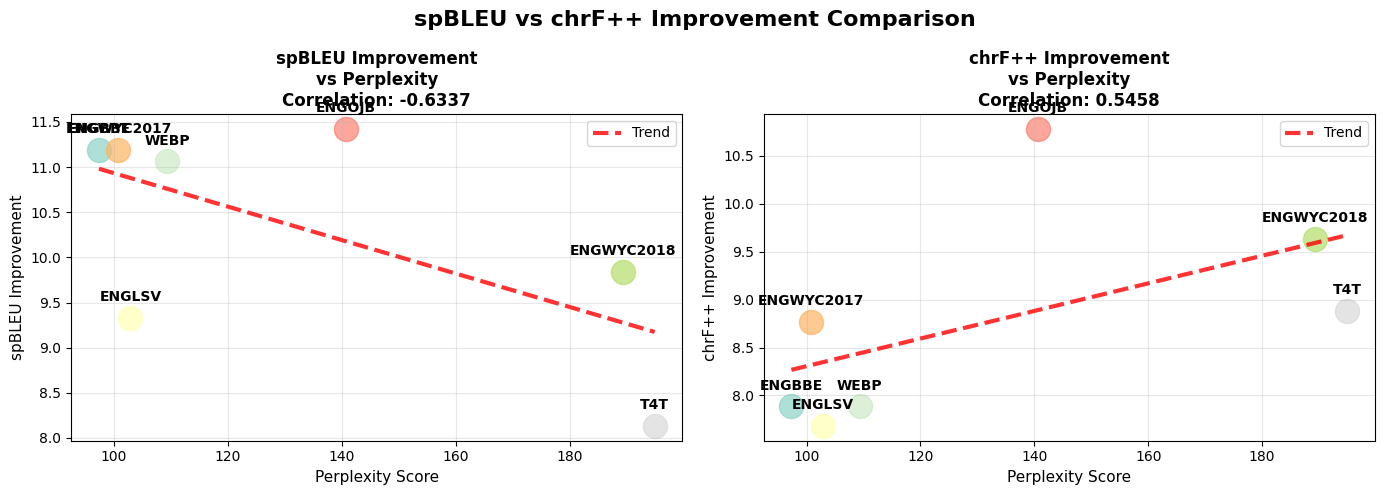

✅ Metric comparison visualization created!

📊 KEY OBSERVATION:
------------------------------------------------------------
The plots show how each metric's improvement relates to perplexity:
• Each variant's position shows its perplexity vs improvement relationship
• Trend lines indicate overall correlation patterns



In [9]:
# VISUALIZATION: Metric comparison across variants
print("\n" + "=" * 80)
print("STEP 9: VISUALIZING METRIC COMPARISON ACROSS VARIANTS")
print("=" * 80)

if len(correlation_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('spBLEU vs chrF++ Improvement Comparison', fontsize=16, fontweight='bold')

    # Create dynamic color map
    unique_variants = correlation_df['variant'].unique()
    colors_map = {variant: plt.cm.Set3(i / len(unique_variants)) for i, variant in enumerate(unique_variants)}

    # 1. spBLEU vs Perplexity
    ax1 = axes[0]
    
    for _, row in correlation_df.iterrows():
        ax1.scatter(row['perplexity_score'], row['spbleu'], 
                    s=300, alpha=0.7, c=[colors_map.get(row['variant'], 'gray')])
        ax1.annotate(row['variant'].upper(), 
                    (row['perplexity_score'], row['spbleu']),
                    textcoords="offset points", xytext=(0,12), ha='center', fontsize=10, fontweight='bold')

    # Trendline
    x_line = np.linspace(correlation_df['perplexity_score'].min(), correlation_df['perplexity_score'].max(), 100)
    z = np.polyfit(correlation_df['perplexity_score'], correlation_df['spbleu'], 1)
    p = np.poly1d(z)
    ax1.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=3, label='Trend')

    corr = correlation_df['perplexity_score'].corr(correlation_df['spbleu'])
    ax1.set_title(f'spBLEU Improvement\nvs Perplexity\nCorrelation: {corr:.4f}', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Perplexity Score', fontsize=11)
    ax1.set_ylabel('spBLEU Improvement', fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # 2. chrF++ vs Perplexity
    ax2 = axes[1]
    
    for _, row in correlation_df.iterrows():
        ax2.scatter(row['perplexity_score'], row['chrf++'], 
                    s=300, alpha=0.7, c=[colors_map.get(row['variant'], 'gray')])
        ax2.annotate(row['variant'].upper(), 
                    (row['perplexity_score'], row['chrf++']),
                    textcoords="offset points", xytext=(0,12), ha='center', fontsize=10, fontweight='bold')

    # Trendline
    z = np.polyfit(correlation_df['perplexity_score'], correlation_df['chrf++'], 1)
    p = np.poly1d(z)
    ax2.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=3, label='Trend')

    corr = correlation_df['perplexity_score'].corr(correlation_df['chrf++'])
    ax2.set_title(f'chrF++ Improvement\nvs Perplexity\nCorrelation: {corr:.4f}', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Perplexity Score', fontsize=11)
    ax2.set_ylabel('chrF++ Improvement', fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print("✅ Metric comparison visualization created!")
    print("\n📊 KEY OBSERVATION:")
    print("-" * 60)
    print("The plots show how each metric's improvement relates to perplexity:")
    print("• Each variant's position shows its perplexity vs improvement relationship")
    print("• Trend lines indicate overall correlation patterns")
else:
    print("⚠️  Insufficient perplexity data for visualization")

print("\n" + "=" * 80)


In [10]:
# CORRELATION ANALYSIS: Perplexity vs FINAL Post-Edited Scores
print("\n" + "=" * 80)
print("STEP 10: PERPLEXITY vs FINAL POST-EDITED PERFORMANCE")
print("=" * 80)

print("\nPrevious analysis looked at IMPROVEMENTS.")
print("Now let's analyze the FINAL POST-EDITED SCORES.\n")

# Merge post-edited scores with perplexity
pe_correlation_df = best_pe_df.merge(perplexity_filtered_df, on='variant', how='inner')

print("📋 FINAL POST-EDITED SCORES BY VARIANT:")
print("-" * 60)
display_cols = ['variant', 'training_config', 'perplexity_score'] + metrics_to_analyze
display_pe_df = pe_correlation_df[display_cols].copy()
display_pe_df = display_pe_df.sort_values('perplexity_score')
display_pe_df['variant'] = display_pe_df['variant'].str.upper()
print(display_pe_df.to_string(index=False))

# Calculate correlations for final scores
print("\n📈 CORRELATION ANALYSIS (Perplexity vs Final Scores):")
print("-" * 60)
print("Correlation between perplexity score and FINAL post-edited metrics:\n")

for metric in metrics_to_analyze:
    corr = pe_correlation_df['perplexity_score'].corr(pe_correlation_df[metric])
    print(f"  {metric:12}: {corr:7.4f}")
    if abs(corr) < 0.3:
        strength = "weak"
    elif abs(corr) < 0.7:
        strength = "moderate"
    else:
        strength = "strong"
    direction = "positive" if corr > 0 else "negative"
    print(f"             ({strength} {direction} correlation)")
    if corr > 0:
        print(f"             → Higher perplexity → Higher final score")
    else:
        print(f"             → Higher perplexity → Lower final score")
    print()

# Calculate average final score
pe_correlation_df['avg_final_score'] = pe_correlation_df[metrics_to_analyze].mean(axis=1)
corr_avg = pe_correlation_df['perplexity_score'].corr(pe_correlation_df['avg_final_score'])

print(f"  {'Avg Final':10}: {corr_avg:7.4f}")
if abs(corr_avg) < 0.3:
    strength = "weak"
elif abs(corr_avg) < 0.7:
    strength = "moderate"
else:
    strength = "strong"
direction = "positive" if corr_avg > 0 else "negative"
print(f"             ({strength} {direction} correlation)")
print(f"             → Average across all metrics")

print("\n💡 INTERPRETATION:")
print("-" * 60)
print("This analysis shows whether perplexity predicts FINAL performance quality,")
print("rather than just the magnitude of improvement from post-editing.")

print("\n" + "=" * 80)



STEP 10: PERPLEXITY vs FINAL POST-EDITED PERFORMANCE

Previous analysis looked at IMPROVEMENTS.
Now let's analyze the FINAL POST-EDITED SCORES.

📋 FINAL POST-EDITED SCORES BY VARIANT:
------------------------------------------------------------
   variant  training_config  perplexity_score  spbleu  chrf++
    ENGBBE parallel_full+nt           97.3408 18.2573 34.3354
ENGWYC2017 parallel_full+nt          100.7690 17.8555 34.6674
    ENGLSV parallel_full+nt          102.8690 16.4850 33.6890
      WEBP parallel_full+nt          109.3180 18.7229 34.9983
    ENGOJB parallel_full+nt          140.6570 15.8632 33.2632
ENGWYC2018 parallel_full+nt          189.3110 15.4383 34.7872
       T4T parallel_full+nt          194.9140 16.0393 35.3239

📈 CORRELATION ANALYSIS (Perplexity vs Final Scores):
------------------------------------------------------------
Correlation between perplexity score and FINAL post-edited metrics:

  spbleu      : -0.7633
             (strong negative correlation)
       


STEP 11: VISUALIZING PERPLEXITY vs FINAL SCORES


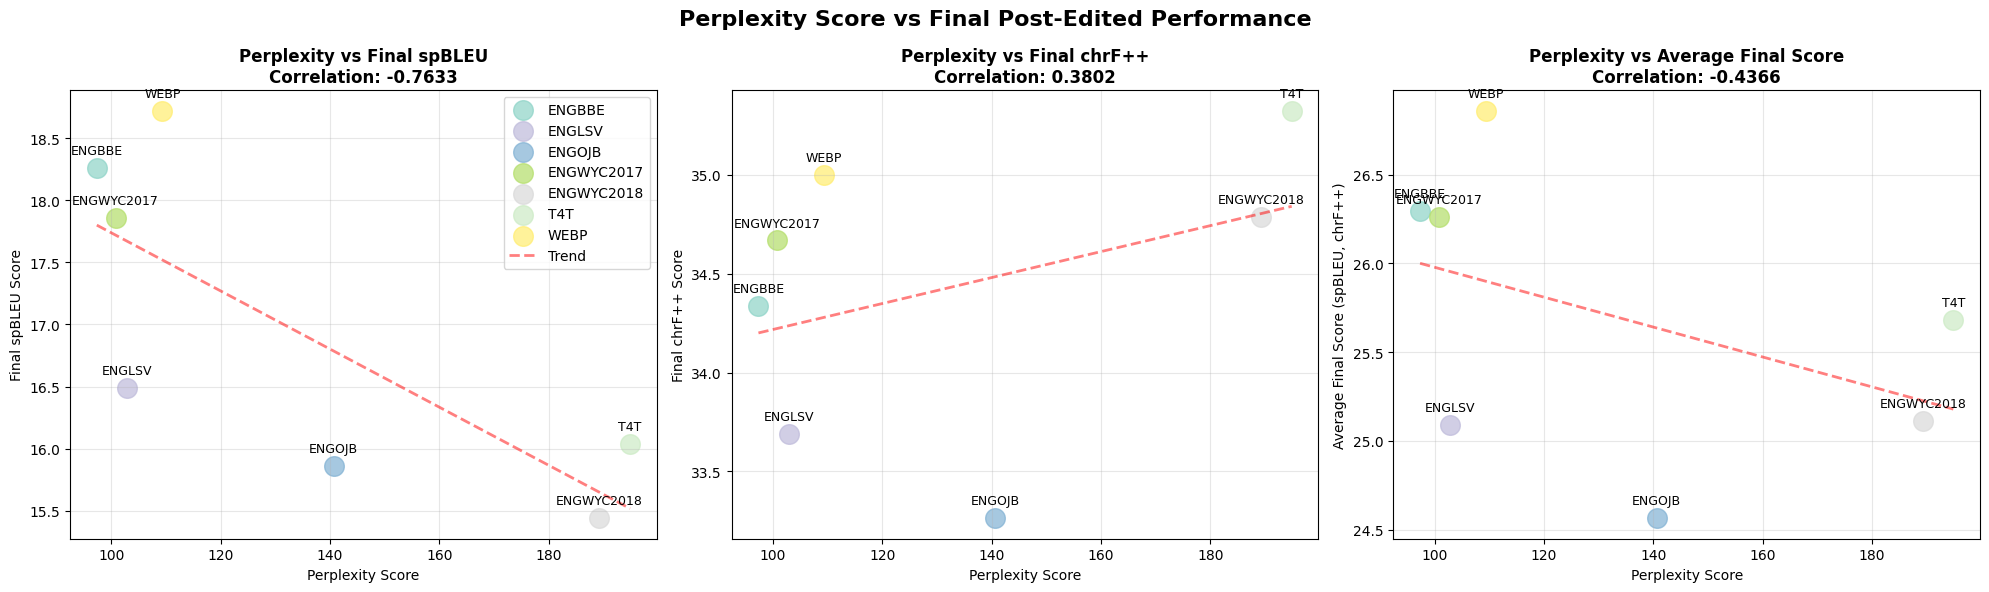

✅ Final score correlation visualizations created!

📊 Key Insights:
   • These plots show if perplexity predicts FINAL performance quality
   • Compare with improvement correlations to see full picture



In [11]:
# VISUALIZATION: Perplexity vs Final Post-Edited Scores
print("\n" + "=" * 80)
print("STEP 11: VISUALIZING PERPLEXITY vs FINAL SCORES")
print("=" * 80)

if len(pe_correlation_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Perplexity Score vs Final Post-Edited Performance (spBLEU & chrF++)', fontsize=16, fontweight='bold')

    # Create dynamic color map
    unique_variants = pe_correlation_df['variant'].unique()
    colors_palette = plt.cm.Set3(np.linspace(0, 1, len(unique_variants)))
    colors_map = {variant: colors_palette[i] for i, variant in enumerate(unique_variants)}
    
    x_line = np.linspace(pe_correlation_df['perplexity_score'].min(), pe_correlation_df['perplexity_score'].max(), 100)

    # 1. Scatter plot: Perplexity vs spBLEU final score
    ax1 = axes[0]
    for _, row in pe_correlation_df.iterrows():
        ax1.scatter(row['perplexity_score'], row['spbleu'], 
                    s=200, alpha=0.7, c=[colors_map.get(row['variant'], 'gray')],
                    label=row['variant'].upper())
        ax1.annotate(row['variant'].upper(), 
                    (row['perplexity_score'], row['spbleu']),
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

    z = np.polyfit(pe_correlation_df['perplexity_score'], pe_correlation_df['spbleu'], 1)
    p = np.poly1d(z)
    ax1.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2, label='Trend')

    corr1 = pe_correlation_df['perplexity_score'].corr(pe_correlation_df['spbleu'])
    ax1.set_title(f'Perplexity vs Final spBLEU\nCorrelation: {corr1:.4f}', fontweight='bold')
    ax1.set_xlabel('Perplexity Score')
    ax1.set_ylabel('Final spBLEU Score')
    ax1.grid(True, alpha=0.3)
    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax1.legend(by_label.values(), by_label.keys(), loc='best')

    # 2. Scatter plot: Perplexity vs chrF++ final score
    ax2 = axes[1]
    for _, row in pe_correlation_df.iterrows():
        ax2.scatter(row['perplexity_score'], row['chrf++'], 
                    s=200, alpha=0.7, c=[colors_map.get(row['variant'], 'gray')])
        ax2.annotate(row['variant'].upper(), 
                    (row['perplexity_score'], row['chrf++']),
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

    z = np.polyfit(pe_correlation_df['perplexity_score'], pe_correlation_df['chrf++'], 1)
    p = np.poly1d(z)
    ax2.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2)

    corr2 = pe_correlation_df['perplexity_score'].corr(pe_correlation_df['chrf++'])
    ax2.set_title(f'Perplexity vs Final chrF++\nCorrelation: {corr2:.4f}', fontweight='bold')
    ax2.set_xlabel('Perplexity Score')
    ax2.set_ylabel('Final chrF++ Score')
    ax2.grid(True, alpha=0.3)
    
    # 3. Scatter plot: Perplexity vs Average final score
    ax3 = axes[2]
    for _, row in pe_correlation_df.iterrows():
        ax3.scatter(row['perplexity_score'], row['avg_final_score'], 
                    s=200, alpha=0.7, c=[colors_map.get(row['variant'], 'gray')])
        ax3.annotate(row['variant'].upper(), 
                    (row['perplexity_score'], row['avg_final_score']),
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

    z = np.polyfit(pe_correlation_df['perplexity_score'], pe_correlation_df['avg_final_score'], 1)
    p = np.poly1d(z)
    ax3.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2)

    corr3 = pe_correlation_df['perplexity_score'].corr(pe_correlation_df['avg_final_score'])
    ax3.set_title(f'Perplexity vs Average Final Score\nCorrelation: {corr3:.4f}', fontweight='bold')
    ax3.set_xlabel('Perplexity Score')
    ax3.set_ylabel('Average Final Score (spBLEU & chrF++)')
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("✅ Final score correlation visualizations created!")
    print("\n📊 Key Insights:")
    print("   • These plots show if perplexity predicts FINAL performance quality")
    print("   • Compare with improvement correlations to see full picture")
else:
    print("⚠️  Insufficient perplexity data for visualization")

print("\n" + "=" * 80)

    # 3. Scatter plot: Perplexity vs Average final score
    ax3 = axes[2]
    for _, row in pe_correlation_df.iterrows():
        ax3.scatter(row['perplexity_score'], row['avg_final_score'], 
                    s=200, alpha=0.7, c=[colors_map.get(row['variant'], 'gray')])
        ax3.annotate(row['variant'].upper(), 
                    (row['perplexity_score'], row['avg_final_score']),
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

    z = np.polyfit(pe_correlation_df['perplexity_score'], pe_correlation_df['avg_final_score'], 1)
    p = np.poly1d(z)
    ax3.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2)

    corr3 = pe_correlation_df['perplexity_score'].corr(pe_correlation_df['avg_final_score'])
    ax3.set_title(f'Perplexity vs Average Final Score\nCorrelation: {corr3:.4f}', fontweight='bold')
    ax3.set_xlabel('Perplexity Score')
    ax3.set_ylabel('Average Final Score (spBLEU, chrF++)')
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("✅ Final score correlation visualizations created!")
    print("\n📊 Key Insights:")
    print("   • These plots show if perplexity predicts FINAL performance quality")
    print("   • Compare with improvement correlations to see full picture")
else:
    print("⚠️  Insufficient perplexity data for visualization")

print("\n" + "=" * 80)
